In [1]:
from kan import KAN
import torch
print("ready")

ready


In [2]:
import torch
import matplotlib.pyplot as plt
from kan import KAN

# Reproduzierbarkeit
torch.manual_seed(0)

# ============================================================
# 1) Datensatz: eine etwas interessantere 1D-Funktion
# ============================================================
def target_function(x):
    # x hat Form [N, 1]
    return 0.5 * x**3 + torch.sin(3.0 * x) + 0.2 * x

n_train = 200
n_test = 200

x_train = torch.linspace(-1, 1, n_train).unsqueeze(1)
y_train = target_function(x_train)

x_test = torch.linspace(-1, 1, n_test).unsqueeze(1)
y_test = target_function(x_test)

dataset = {
    'train_input': x_train,
    'train_label': y_train,
    'test_input': x_test,
    'test_label': y_test
}

# ============================================================
# 2) KAN-Modell
# ============================================================
model = KAN(width=[1, 6, 1], grid=5, k=3, seed=0)

# ============================================================
# 3) Training
# ============================================================
# pyKAN trainiert oft mit LBFGS gut
results = model.train(
    dataset,
    opt="LBFGS",
    steps=50,
    lamb=0.001,          # leichte Regularisierung
    lamb_entropy=2.0     # fördert Sparsity / Interpretierbarkeit
)

# Optional: noch ein bisschen Feintuning mit Adam
results_adam = model.train(
    dataset,
    opt="Adam",
    steps=100,
    lr=0.01,
    lamb=0.001,
    lamb_entropy=2.0
)

# ============================================================
# 4) Vorhersage und Vergleich plotten
# ============================================================
with torch.no_grad():
    y_pred = model(x_test)

plt.figure(figsize=(8, 5))
plt.plot(x_test.numpy(), y_test.numpy(), label='True function')
plt.plot(x_test.numpy(), y_pred.numpy(), '--', label='KAN prediction')
plt.xlabel('x')
plt.ylabel('y')
plt.title('pyKAN: Funktionsapproximation')
plt.legend()
plt.grid(True)
plt.show()

# ============================================================
# 5) Trainingsverlauf plotten
# ============================================================
plt.figure(figsize=(8, 5))
if 'train_loss' in results:
    plt.plot(results['train_loss'], label='LBFGS train loss')
if 'test_loss' in results:
    plt.plot(results['test_loss'], label='LBFGS test loss')

if 'train_loss' in results_adam:
    plt.plot(
        range(len(results.get('train_loss', [])),
              len(results.get('train_loss', [])) + len(results_adam['train_loss'])),
        results_adam['train_loss'],
        label='Adam train loss'
    )
if 'test_loss' in results_adam:
    plt.plot(
        range(len(results.get('test_loss', [])),
              len(results.get('test_loss', [])) + len(results_adam['test_loss'])),
        results_adam['test_loss'],
        label='Adam test loss'
    )

plt.yscale('log')
plt.xlabel('Training step')
plt.ylabel('Loss')
plt.title('Trainingsverlauf')
plt.legend()
plt.grid(True)
plt.show()

# ============================================================
# 6) KAN-Diagramm plotten
#    -> zeigt die gelernten Funktionen auf den Kanten
# ============================================================
# In pyKAN ist plot() genau dafür gedacht
model.plot()

# ============================================================
# 7) Symbolische Regression / Symbolic branch aktivieren
# ============================================================
# Manche pyKAN-Versionen brauchen erst auto_symbolic()
# Das versucht, numerische Splines durch symbolische Ausdrücke zu ersetzen
try:
    model.auto_symbolic()
    print("auto_symbolic() erfolgreich.")
except Exception as e:
    print("auto_symbolic() nicht verfügbar oder fehlgeschlagen:")
    print(e)

# Nach auto_symbolic() erneut plotten, um symbolische Kanten zu sehen
try:
    model.plot()
except Exception as e:
    print("plot() nach auto_symbolic() fehlgeschlagen:")
    print(e)

# ============================================================
# 8) Symbolische Formel ausgeben
# ============================================================
# Je nach pyKAN-Version können die verfügbaren Methoden leicht variieren
for method_name in ["symbolic_formula", "formula", "expr"]:
    if hasattr(model, method_name):
        try:
            formula = getattr(model, method_name)()
            print(f"\nSymbolische Ausgabe über {method_name}():")
            print(formula)
            break
        except Exception as e:
            print(f"{method_name}() vorhanden, aber fehlgeschlagen:")
            print(e)

checkpoint directory created: ./model
saving model version 0.0


TypeError: Module.train() got an unexpected keyword argument 'opt'

checkpoint directory created: ./model
saving model version 0.0
Epoch 0, Loss: 1.019529
Epoch 50, Loss: 0.014564
Epoch 100, Loss: 0.001664
Epoch 150, Loss: 0.000042
Epoch 200, Loss: 0.000005
Epoch 250, Loss: 0.000003
Epoch 300, Loss: 0.000002
Epoch 350, Loss: 0.000001
Epoch 400, Loss: 0.000001
Epoch 450, Loss: 0.000000


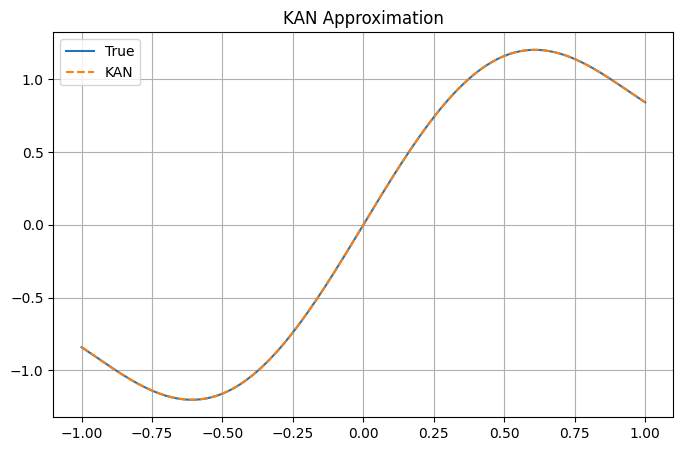

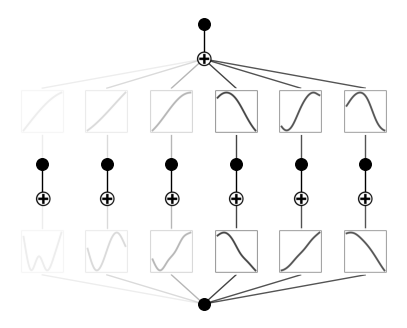

In [3]:
import torch
import matplotlib.pyplot as plt
from kan import KAN

torch.manual_seed(0)

# ============================================================
# 1) Daten
# ============================================================
def target_function(x):
    return 0.5 * x**3 + torch.sin(3.0 * x) + 0.2 * x

x = torch.linspace(-1, 1, 200).unsqueeze(1)
y = target_function(x)

# ============================================================
# 2) Modell
# ============================================================
model = KAN(width=[1, 6, 1], grid=5, k=3)

# GANZ WICHTIG:
model.train()   # nur Modus setzen!

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# ============================================================
# 3) Training
# ============================================================
for epoch in range(500):
    optimizer.zero_grad()
    
    y_pred = model(x)
    loss = torch.mean((y_pred - y)**2)
    
    loss.backward()
    optimizer.step()
    
    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

# ============================================================
# 4) Ergebnis plotten
# ============================================================
model.eval()

with torch.no_grad():
    y_pred = model(x)

plt.figure(figsize=(8,5))
plt.plot(x.numpy(), y.numpy(), label="True")
plt.plot(x.numpy(), y_pred.numpy(), "--", label="KAN")
plt.legend()
plt.title("KAN Approximation")
plt.grid()
plt.show()

# ============================================================
# 5) KAN-Diagramm (das willst du!)
# ============================================================
model.plot()